# 实验 05：完整记忆库中的 Jacobian 秩坍缩

确认性主问题是：

> 在第一步竞争程度相同的条件下，softmax 与 sparsemax 保留输入方向的速度是否仍然不同？

输入是 8 个独立的 `N=128, K=100` 记忆库，以及噪声率 $\rho\in\{0.10,0.25,0.40\}$ 的查询。每一步使用全部 100 条记忆。程序先用非留出目标选择各方法的 $\alpha$，再用 32 个预注册留出目标检查第一步 IPR（参与竞争的有效记忆数）是否匹配。

只有全部条件对的留出 IPR 相对差不超过 5%，才允许计算 seed 级 `dimension_auc` 差异和 bootstrap 置信区间。匹配失败时，结果是 **05A 不可检验**，不能解释成“两条秩曲线没有差异”。

## 1. 下载并核对冻结源码

Notebook 固定到提交 `92b2f76`。核心脚本、protocol 和开发阶段冻结的 IPR 水平逐一核对 SHA-256；任一文件不一致便停止。

In [1]:
import hashlib
import importlib.util
from pathlib import Path
import subprocess
import sys
import urllib.request

required = {
    "torch": "torch",
    "entmax": "entmax==1.3",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

CODE_REV = "92b2f7672d9d426fc9d76f5cf4492052a91ddb9f"
BASE = Path("/content/hopfield-dynamic-geometry")
SOURCES = {
    "experiment_05_multimemory_rank_collapse.py": "6e0fb9b3728600dbb1bf2812acde3df8fcc1f15b31cc6055cee2cb39557402ce",
    "experiment_05_multimemory_rank_collapse_protocol.md": "cad90cbff17b69d231ba165822317350c5cd7b6daf6c1bfb7639484a968aecba",
    "artifacts/experiment_05/development/matched_ipr_levels.csv": "9b708f087b1b9012c3d948f83c45b17f78b642324e5e36b5711f11429c5280cc",
}
BASE.mkdir(parents=True, exist_ok=True)
raw_root = f"https://raw.githubusercontent.com/Heptazero/nn-labs/{CODE_REV}/representation-geometry/experiments/hopfield-dynamic-geometry"
for relative, expected in SOURCES.items():
    target = BASE / Path(relative).name
    urllib.request.urlretrieve(f"{raw_root}/{relative}", target)
    actual = hashlib.sha256(target.read_bytes()).hexdigest()
    if actual != expected:
        raise RuntimeError(f"SHA-256 mismatch for {relative}: {actual}")
if str(BASE) not in sys.path:
    sys.path.insert(0, str(BASE))
print("verified source revision:", CODE_REV)

verified source revision: 92b2f7672d9d426fc9d76f5cf4492052a91ddb9f


## 2. 变换、输出与停止门

对每条轨迹同时记录一步局部 Jacobian $A_t=DF(x_t)$ 与累计 Jacobian $J_t=\partial x_t/\partial x_0$。$G_t=J_t^\top J_t$ 的谱给出仍存活的输入方向，主指标是

$$d_t=\frac{r_{eff}(t)-1}{r_{eff}(1)-1},\qquad
\mathrm{dimension\_auc}=\operatorname{mean}_{t=1}^{12}d_t.$$

程序还会分开计算 within-target rank（同一记忆的噪声是否被压缩）和 between-target rank（不同记忆是否被错误合并）。低 IPR 下第一步即只剩一个方向，以及后续总敏感度灭绝，都会显式保存。

05A 通过必须同时满足：全部 IPR 条件匹配；seed 配对差的绝对值至少 0.10；95% bootstrap CI 不跨 0。任一 IPR 条件不匹配时，确认性差值与 CI 保持为空，并停止 05B。

formal 05A memory seed 1/8
formal 05A memory seed 2/8
formal 05A memory seed 3/8
formal 05A memory seed 4/8
formal 05A memory seed 5/8
formal 05A memory seed 6/8
formal 05A memory seed 7/8
formal 05A memory seed 8/8


{'status': 'formal_05A',
 'all_ipr_conditions_matched': False,
 'all_seed_self_checks_passed': True,
 'complete_rank_records': False,
 'expected_rank_rows': 59904,
 'expected_rows_for_matched_subset': 49920,
 'actual_rank_rows': 49920,
 'matched_subset_records_complete': True,
 'unexpected_nonfinite_after_entry': 0,
 'unmatched_condition_pairs': 12,
 'total_condition_pairs': 72,
 'ipr_matching_by_rho_level': [{'rho': 0.1,
   'level': 'high',
   'matched_seeds': 8,
   'total_seeds': 8},
  {'rho': 0.1, 'level': 'low', 'matched_seeds': 8, 'total_seeds': 8},
  {'rho': 0.1, 'level': 'middle', 'matched_seeds': 8, 'total_seeds': 8},
  {'rho': 0.25, 'level': 'high', 'matched_seeds': 8, 'total_seeds': 8},
  {'rho': 0.25, 'level': 'low', 'matched_seeds': 8, 'total_seeds': 8},
  {'rho': 0.25, 'level': 'middle', 'matched_seeds': 4, 'total_seeds': 8},
  {'rho': 0.4, 'level': 'high', 'matched_seeds': 8, 'total_seeds': 8},
  {'rho': 0.4, 'level': 'low', 'matched_seeds': 4, 'total_seeds': 8},
  {'rho'

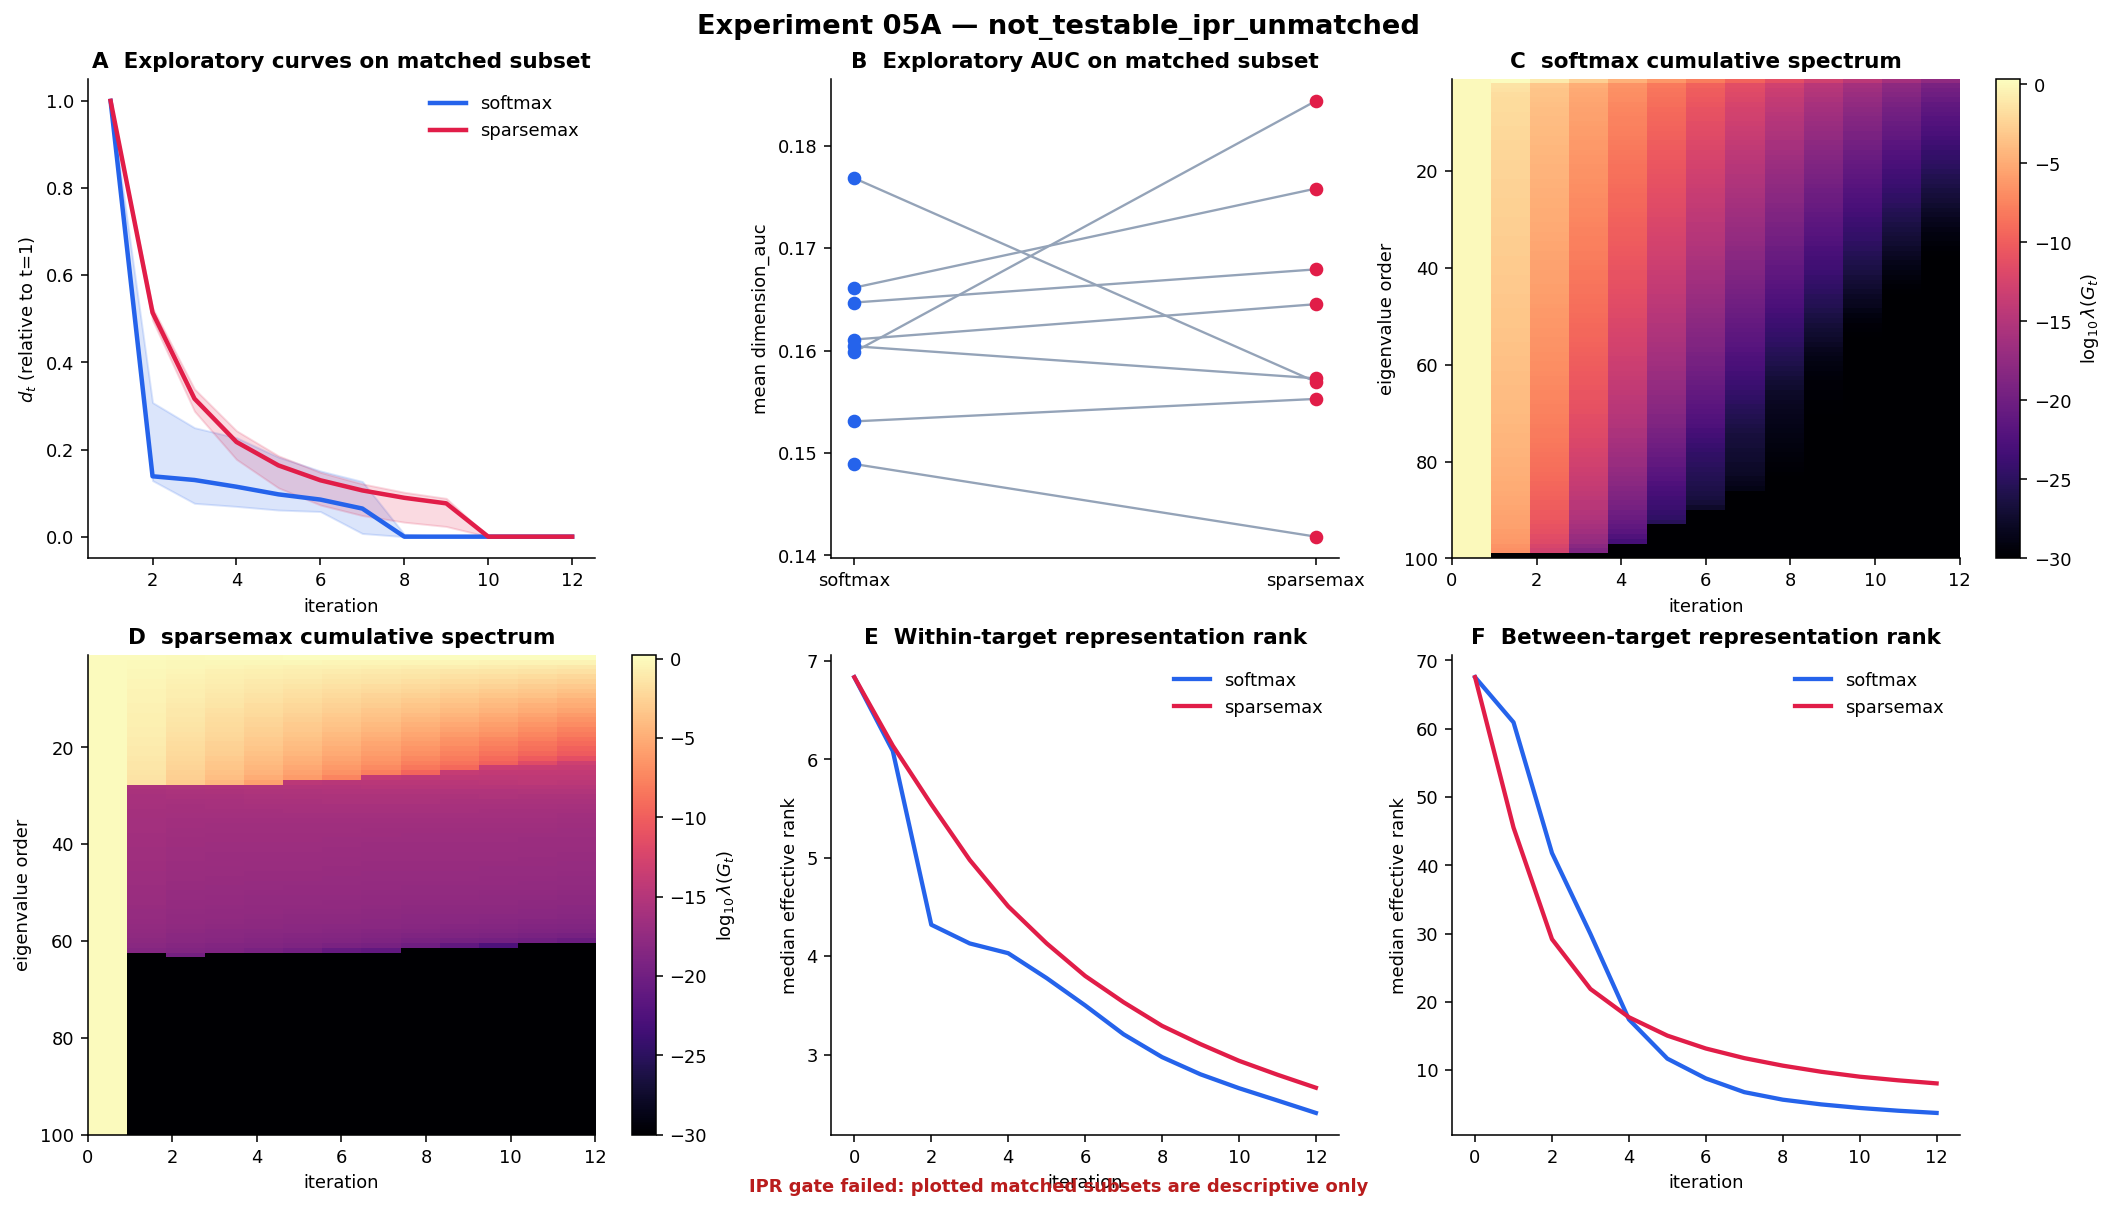

In [2]:
import pandas as pd
from experiment_05_multimemory_rank_collapse import (
    RankCollapseConfig,
    run_formal_05A,
)

config = RankCollapseConfig()
frozen_levels = pd.read_csv(BASE / "matched_ipr_levels.csv")
output_dir = Path("/content/experiment_05_formal")
summary = run_formal_05A(config, frozen_levels, output_dir)
summary

## 3. 先判定 IPR 门，再看图

下面先显示每个噪声率和 IPR 档位有多少 seed 匹配。若 `all_ipr_conditions_matched=False`，后面的曲线只是已匹配子集的描述，不能用来接受或拒绝 05A。

In [3]:
import json
from IPython.display import display

match_table = pd.read_csv(output_dir / "ipr_matching_by_rho_level.csv")
unmatched = pd.read_csv(output_dir / "unmatched_conditions.csv")
self_checks = pd.read_csv(output_dir / "self_checks.csv")

display(match_table)
print("unmatched condition pairs:", summary["unmatched_condition_pairs"], "/", summary["total_condition_pairs"])
display(unmatched[[
    "memory_seed", "rho", "level", "method", "target_ipr", "alpha",
    "training_relative_error", "heldout_median_ipr",
    "heldout_pair_relative_error", "matched",
]])
print("all 56 numerical checks passed:", bool(self_checks["passed"].all()))
print(json.dumps(summary, indent=2, ensure_ascii=False))

assert summary["all_seed_self_checks_passed"]
assert summary["matched_subset_records_complete"]
assert summary["unexpected_nonfinite_after_entry"] == 0

,rho,level,matched_seeds,total_seeds
0,0.10,high,8,8
1,0.10,low,8,8
2,0.10,middle,8,8
3,0.25,high,8,8
4,0.25,low,8,8
5,0.25,middle,4,8
6,0.40,high,8,8
7,0.40,low,4,8
8,0.40,middle,4,8


unmatched condition pairs: 12 / 72


,memory_seed,rho,level,method,target_ipr,alpha,training_relative_error,heldout_median_ipr,heldout_pair_relative_error,matched
0,0,0.25,middle,softmax,8.064166,8.50,0.064763,7.662659,0.032943,False
1,0,0.25,middle,sparsemax,8.064166,0.70,0.039759,7.919316,0.032943,False
2,1,0.40,low,softmax,2.824341,48.00,0.081424,3.557621,0.073119,False
3,1,0.40,low,sparsemax,2.824341,8.00,0.003949,3.306667,0.073119,False
4,1,0.40,middle,softmax,15.279073,19.00,0.010304,16.768539,0.120307,False
5,1,0.40,middle,sparsemax,15.279073,0.75,0.028020,14.865640,0.120307,False
6,2,0.40,low,softmax,2.824341,48.00,0.143793,2.659257,0.076996,False
7,2,0.40,low,sparsemax,2.824341,7.50,0.009812,2.872208,0.076996,False
8,2,0.40,middle,softmax,15.279073,20.00,0.038277,13.580486,0.110868,False
9,2,0.40,middle,sparsemax,15.279073,0.75,0.012786,15.174487,0.110868,False


all 56 numerical checks passed: True
{
  "status": "formal_05A",
  "all_ipr_conditions_matched": false,
  "all_seed_self_checks_passed": true,
  "complete_rank_records": false,
  "expected_rank_rows": 59904,
  "expected_rows_for_matched_subset": 49920,
  "actual_rank_rows": 49920,
  "matched_subset_records_complete": true,
  "unexpected_nonfinite_after_entry": 0,
  "unmatched_condition_pairs": 12,
  "total_condition_pairs": 72,
  "ipr_matching_by_rho_level": [
    {
      "rho": 0.1,
      "level": "high",
      "matched_seeds": 8,
      "total_seeds": 8
    },
    {
      "rho": 0.1,
      "level": "low",
      "matched_seeds": 8,
      "total_seeds": 8
    },
    {
      "rho": 0.1,
      "level": "middle",
      "matched_seeds": 8,
      "total_seeds": 8
    },
    {
      "rho": 0.25,
      "level": "high",
      "matched_seeds": 8,
      "total_seeds": 8
    },
    {
      "rho": 0.25,
      "level": "low",
      "matched_seeds": 8,
      "total_seeds": 8
    },
    {
      "rho":

## 4. 主图与自动判定

当 IPR 门失败时，图题和页脚会标记 `not_testable_ipr_unmatched`。A、B 只显示已匹配子集；C、D 是累计 Jacobian 谱；E、F 分别是目标内和目标间表示秩。

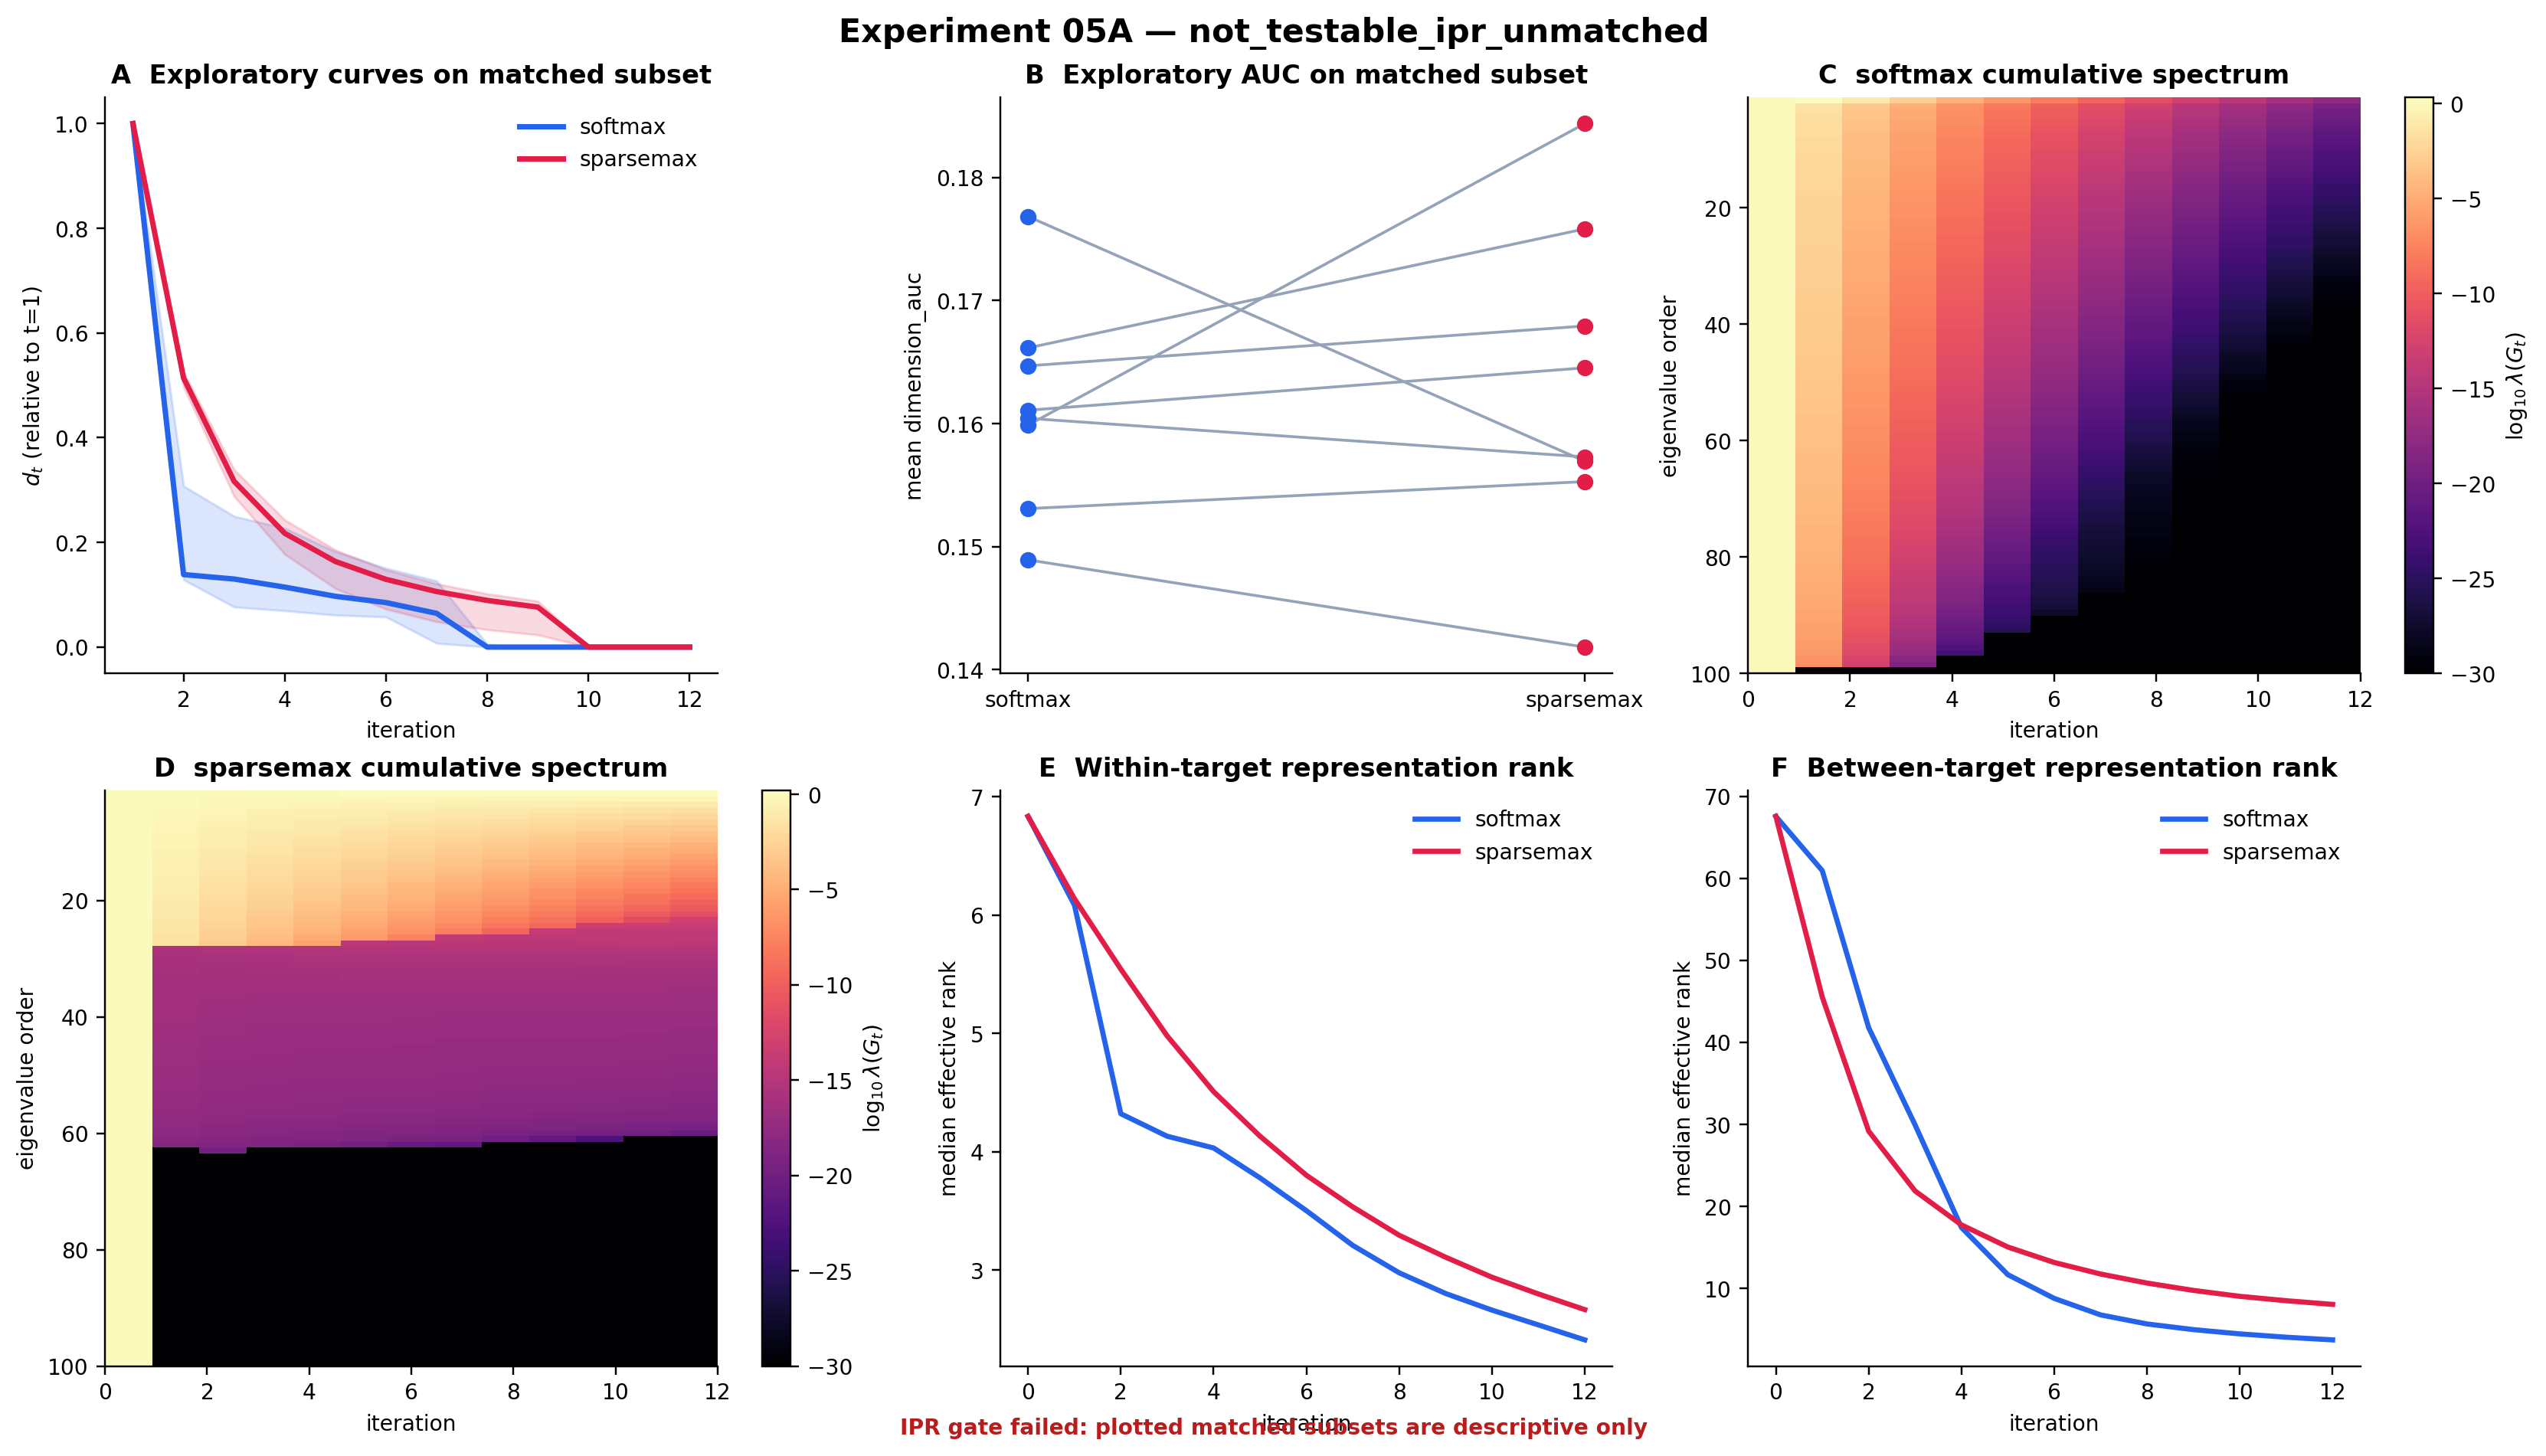

# 实验 05A 判定

本次正式运行未能检验 softmax 与 sparsemax 的秩坍缩差异。12/72 个 `seed × rho × IPR level` 条件对未通过冻结的 5% IPR 匹配门，因此不计算确认性配对差或置信区间。

数值自检与已匹配子集的数据完整性均通过；匹配子集图只作描述，不能据此接受或拒绝 05A。按预注册规则，不扩展 alpha 网格、不放宽阈值，也不进入 05B。



In [4]:
from IPython.display import Image

display(Image(filename=str(output_dir / "main_figure.png")))
print((output_dir / "conclusion.md").read_text())

## 5. 仓库冻结运行的结果

仓库中保存的同配置 CPU 正式预算运行得到：56/56 数值自检通过，但 72 个 `seed × rho × IPR level` 条件对中有 12 个未通过 5% 匹配门。失败集中在 `rho=0.25` 中档，以及 `rho=0.40` 的低档和中档；这三组都只有 4/8 seed 匹配。

因此确认性 `dimension_auc` 差值和置信区间没有计算，05A 记为 `not_testable_ipr_unmatched`，05B 未运行。代码没有再次扩展 alpha 网格，也没有放宽 5% 阈值。

## 6. 下载全部正式产物

In [5]:
import shutil
from google.colab import files

archive = shutil.make_archive(
    "/content/experiment_05_formal_artifacts", "zip", root_dir=output_dir
)
print("archive:", archive)
files.download(archive)

archive: /content/experiment_05_formal_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>